# Classificação das condicoes da helice com KNN

Este notebook segue o fluxo usado no arquivo `KNN_training.py`, usando os dados da pasta `dados`.

A ideia principal e:

1. Ler as planilhas de cada condicao.
2. Separar o trecho de regime permanente.
3. Dividir o regime permanente em janelas.
4. Extrair estatisticas de cada janela.
5. Treinar um modelo KNN.
6. Avaliar com validacao cruzada agrupada por arquivo.

A validacao agrupada por arquivo e importante porque impede que janelas da mesma planilha aparecam ao mesmo tempo no treino e no teste.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 1. Caminhos dos dados

Cada subpasta representa uma classe do problema.

In [2]:
THIS_FOLDER = os.getcwd()
DATA_FOLDER = os.path.join(THIS_FOLDER, "dados")

FOLDERS = {
    "normal": os.path.join(DATA_FOLDER, "normal"),
    "desbalanceada": os.path.join(DATA_FOLDER, "helice_desbalanceada"),
    "quebrada": os.path.join(DATA_FOLDER, "helice_quebrada"),
    "invertida": os.path.join(DATA_FOLDER, "rotacao_invertida"),
}

DROP_COLUMNS = ["Celula3_Kgf", "Tempo", "RPM"]

for condicao, folder in FOLDERS.items():
    arquivos = [name for name in os.listdir(folder) if name.endswith(".xlsx")]
    print(f"{condicao}: {len(arquivos)} arquivos")

normal: 4 arquivos
desbalanceada: 4 arquivos
quebrada: 5 arquivos
invertida: 3 arquivos


## 2. Funcao para separar transitorio e regime permanente

A funcao abaixo usa a corrente (`Corrente_A`) para localizar o trecho de regime permanente. O modelo sera treinado apenas com esse trecho.

In [3]:
def transitory_stacionary(df):
    loc_i = df.columns.get_loc("Corrente_A") + 1

    q1 = df["Corrente_A"].quantile(0.30)
    q3 = df["Corrente_A"].quantile(0.70)
    df_40 = df[(df["Corrente_A"] >= q1) & (df["Corrente_A"] <= q3)]

    flag_stac = False
    flag_transitory_1 = True
    transitory_1 = 0
    transitory_2 = None
    mean = df_40["Corrente_A"].mean()

    for idx, row in enumerate(df.itertuples()):
        corrente = abs(row[loc_i])

        if 0.99 * mean <= corrente <= 1.3 * mean and flag_transitory_1:
            transitory_1 = idx + 12
            flag_stac = True
            flag_transitory_1 = False

        if flag_stac and 0.3 * mean <= corrente <= 0.82 * mean:
            transitory_2 = idx - 8
            break

    df_0 = df.iloc[:transitory_1]

    if transitory_2 is not None:
        df_1 = df.iloc[transitory_1:transitory_2]
        df_2 = df.iloc[transitory_2:]
    else:
        df_1 = df.iloc[transitory_1:]
        df_2 = None

    return df_0, df_1, df_2

## 3. Extração de estatisticas por janela

Aqui esta a diferenca importante: as estatisticas sao calculadas usando a propria `janela`, e nao o `df_regime` inteiro. Isso evita repetir a mesma informacao em varias linhas.

In [4]:
def window_statistics(df, condicao, arquivo):
    row = {"condicao": condicao, "arquivo": arquivo}

    for coluna in df.columns:
        valores = df[coluna]
        row[f"{coluna}_mean"] = valores.mean()
        row[f"{coluna}_std"] = valores.std()
        row[f"{coluna}_max"] = valores.max()
        row[f"{coluna}_min"] = valores.min()
        row[f"{coluna}_median"] = valores.median()
        row[f"{coluna}_skew"] = valores.skew()
        row[f"{coluna}_kurtosis"] = valores.kurtosis()
        row[f"{coluna}_rms"] = np.sqrt(np.mean(valores**2))

    return row

In [5]:
def extract_features(window_length=300):
    dados_extraidos = []

    for condicao, folder in FOLDERS.items():
        files = [
            os.path.join(folder, name)
            for name in os.listdir(folder)
            if name.endswith(".xlsx")
        ]

        for file_path in files:
            df = pd.read_excel(file_path)
            df = df.drop(columns=DROP_COLUMNS, errors="ignore")

            _, df_regime, _ = transitory_stacionary(df)

            if df_regime.empty:
                print(f"Aviso: regime permanente vazio em {os.path.basename(file_path)}")
                continue

            for inicio in range(0, len(df_regime), window_length):
                janela = df_regime.iloc[inicio : inicio + window_length]

                if not janela.empty:
                    dados_extraidos.append(
                        window_statistics(
                            janela,
                            condicao=condicao,
                            arquivo=os.path.basename(file_path),
                        )
                    )

    return pd.DataFrame(dados_extraidos)

## 4. Montagem da base final

A coluna `condicao` e o rotulo que o KNN deve prever. A coluna `arquivo` sera usada apenas para garantir que a validacao respeite a origem dos dados.

In [6]:
features = extract_features(window_length=300)

print("Total de janelas:", len(features))
print("Arquivos originais:", features["arquivo"].nunique())
display(features.head())

Total de janelas: 31
Arquivos originais: 16


,condicao,arquivo,Celula1_Kgf_mean,Celula1_Kgf_std,Celula1_Kgf_max,Celula1_Kgf_min,Celula1_Kgf_median,Celula1_Kgf_skew,Celula1_Kgf_kurtosis,Celula1_Kgf_rms,...,Corrente_A_kurtosis,Corrente_A_rms,Potencia_W_mean,Potencia_W_std,Potencia_W_max,Potencia_W_min,Potencia_W_median,Potencia_W_skew,Potencia_W_kurtosis,Potencia_W_rms
0,normal,primeiroteste_helicenormal.xlsx,-663.646667,19.501869,-616,-785,-666.0,-2.120935,11.722684,663.932190,...,-0.619901,34.933065,481.739008,30.095312,520.9536,378.4848,495.27375,-0.655186,-0.506603,482.675026
1,normal,primeiroteste_helicenormal.xlsx,-666.063063,3.890032,-658,-673,-666.0,0.224886,-0.418845,666.074320,...,2.361490,36.350723,497.436339,17.468196,523.1736,425.9324,502.33440,-1.307813,1.825273,497.740193
2,normal,quartoteste_helicenormal.xlsx,-633.746667,77.294051,-19,-699,-639.0,6.897748,52.067275,638.427203,...,1.786768,31.782128,443.922523,16.639767,510.1100,414.4770,441.87175,1.399411,2.465354,444.233233
3,normal,quartoteste_helicenormal.xlsx,-614.325301,4.480604,-598,-621,-615.0,1.661835,3.540774,614.341444,...,2.473586,30.621656,415.332837,13.662465,437.4348,363.9530,418.57200,-1.279559,2.061852,415.554786
4,normal,segundoteste_helicenormal.xlsx,-628.753333,18.284792,-604,-683,-625.0,-0.982940,0.619109,629.018262,...,1.864570,28.965296,383.504425,13.114072,419.1015,327.5194,383.79200,-0.277156,0.990665,383.727833


In [7]:
features["condicao"].value_counts()

condicao
quebrada         9
normal           8
desbalanceada    8
invertida        6
Name: count, dtype: int64

## 5. Separacao entre features, rotulos e grupos

- `X`: estatisticas usadas pelo modelo.
- `y`: condicao da helice.
- `groups`: nome do arquivo original, usado na validacao cruzada agrupada.

In [8]:
groups = features["arquivo"]
X = features.drop(columns=["condicao", "arquivo"])
y = features["condicao"]

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (31, 40)
Formato de y: (31,)


## 6. Pipeline do KNN

O `StandardScaler` e necessario porque o KNN depende de distancia. Sem normalizacao, variaveis com escala maior dominam o calculo de vizinhanca.

In [9]:
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ]
)

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

## 7. Busca dos melhores hiperparametros

A metrica usada e `balanced_accuracy`, pois ela considera melhor o desempenho entre classes quando ha diferenca na quantidade de amostras.

In [10]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1,
)

grid_search.fit(X, y, groups=groups)

print("Melhores hiperparametros:", grid_search.best_params_)
print("Melhor balanced accuracy media:", grid_search.best_score_)

Melhores hiperparametros: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Melhor balanced accuracy media: 0.8208333333333333


## 8. Avaliacao com predicoes fora do grupo

Nesta etapa, cada predicao e feita em uma dobra onde o arquivo original daquela janela nao foi usado no treino.

In [11]:
best_model = grid_search.best_estimator_

y_pred = cross_val_predict(
    best_model,
    X,
    y,
    groups=groups,
    cv=cv,
    n_jobs=-1,
)

print(classification_report(y, y_pred, zero_division=0))

               precision    recall  f1-score   support

desbalanceada       0.67      0.50      0.57         8
    invertida       1.00      1.00      1.00         6
       normal       0.86      0.75      0.80         8
     quebrada       0.58      0.78      0.67         9

     accuracy                           0.74        31
    macro avg       0.78      0.76      0.76        31
 weighted avg       0.76      0.74      0.74        31



## 9. Matriz de confusao

As linhas representam a classe real e as colunas representam a classe prevista.

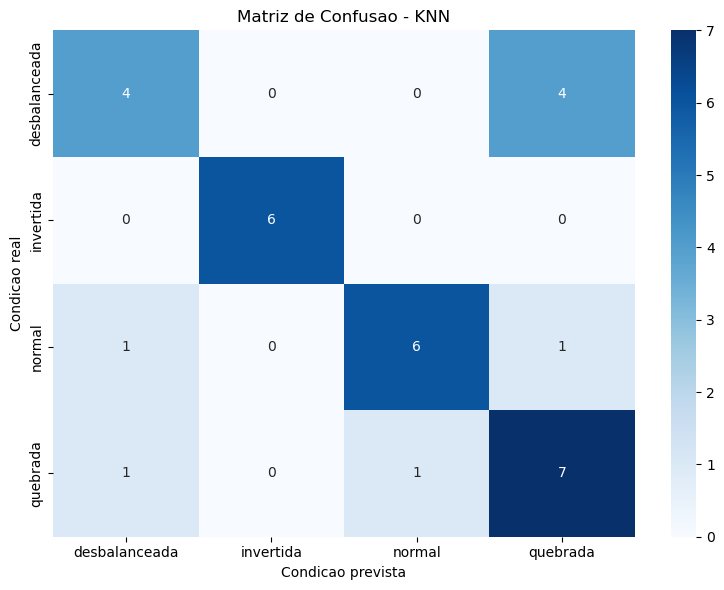

In [12]:
labels = best_model.classes_
cm = confusion_matrix(y, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.title("Matriz de Confusao - KNN")
plt.ylabel("Condicao real")
plt.xlabel("Condicao prevista")
plt.tight_layout()
plt.show()

## 10. Conclusao

Este procedimento e mais adequado do que separar janelas aleatoriamente, porque respeita a origem das amostras. Assim, o resultado representa melhor a capacidade do modelo de classificar uma nova planilha/medicao, e nao apenas novas janelas muito parecidas com as que ele ja viu.